# 🏦 Neobank Analytics: End-to-End Quantitative Fintech EDA & SQL Modeling
### Advanced Unit Economics, Cohort Retention, Pricing Elasticity, Cross-Selling & Lifecycle Analytics

**Author:** Nico Carello  
**Repository:** [github.com/Nicocarello/neobank-data-ai](https://github.com/Nicocarello/neobank-data-ai)  
**Live BI Dashboard:** [Looker Studio Executive Report](https://datastudio.google.com/reporting/896e4bb8-b2d6-4fd4-8398-96cfa992f738/page/9TmAG)

---

## 🎯 Executive Overview & Analytical Framework
This notebook delivers a production-grade **Fintech & Data Science audit** for a multi-country neobank operating across Latin America (**Argentina, Chile, Colombia, México, Perú**). 

Applying domain principles from payment engineering, money movement topology, and treasury controls, this study investigates:
1. **Multicurrency Normalization & Core KPIs:** Unifying heterogeneous local currencies (ARS, CLP, COP, MXN, PEN) into standard USD volume and Gross Revenue.
2. **Monthly Trajectory & Margin Stability:** Tracking month-over-month volume, revenue, and take rate resilience across 2024–2025.
3. **Product Portfolio Dynamics:** Dissecting the 4 core verticals (**Remesa, Exchange, Tarjeta, P2P**).
4. **Money Movement Topology:** Cross-border corridor traffic vs. domestic rail clearing.
5. **Monetization Architecture & Discount Dilution:** Auditing Gross vs. Net Take Rate and promotional drag.
6. **Pricing Elasticity & Fee Drag:** Exploring ticket size regressivity and minimum fee impact.
7. **Customer Cohort Retention (M0–M12):** Triangular retention matrix proving product stickiness and PMF.
8. **Wallet Depth & Cross-Sell Multiplier:** Measuring the revenue expansion of multi-product adopters.
9. **Portfolio Concentration & Whale Risk:** Quantifying counterparty exposure via Lorenz curve and Pareto analysis.
10. **Customer Recency & Dormancy Risk Engine:** Segmenting active, cooling-off, and dormant accounts to drive win-back strategies.
11. **Account Activation Auditing:** Identifying 0-transaction accounts via SQL `LEFT JOIN`.
12. **Relational ANSI SQL Modeling:** Production-grade Window Functions (`DENSE_RANK`, `ROW_NUMBER`) and CTEs.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.autolayout'] = True
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Database connection to audited SQLite replica
conn = sqlite3.connect('neobank.db')
print("Successfully connected to neobank.db (SQLite)")


Successfully connected to neobank.db (SQLite)


In [2]:
# Load relational tables into DataFrames
df_customers = pd.read_sql('SELECT * FROM customer', conn)
df_transactions = pd.read_sql('SELECT * FROM "transaction"', conn)

# Parse ISO timestamps
df_transactions['transaction_datetime'] = pd.to_datetime(df_transactions['transaction_datetime'])
df_customers['created_at'] = pd.to_datetime(df_customers['created_at'])

print(f"Customers dataset:    {df_customers.shape[0]:,} rows, {df_customers.shape[1]} columns")
print(f"Transactions dataset: {df_transactions.shape[0]:,} rows, {df_transactions.shape[1]} columns")
print(f"Audited date window:  {df_transactions['transaction_datetime'].min().date()} to {df_transactions['transaction_datetime'].max().date()}")


Customers dataset:    1,000 rows, 7 columns
Transactions dataset: 5,000 rows, 17 columns
Audited date window:  2024-01-02 to 2025-01-22


In [3]:
# Preview top 5 transactional records across multi-currency columns
df_transactions[['transaction_id', 'customer_id', 'product', 'origin_country', 'destiny_country', 'origin_amount_usd', 'revenue', 'transaction_datetime']].head()


transaction_id,customer_id,product,origin_country,destiny_country,origin_amount_usd,revenue,transaction_datetime
1,967,Tarjeta,México,Chile,2488.09,463.67,2024-12-29 06:55:30
2,457,P2P,Colombia,México,1986.93,485.15,2024-12-26 15:58:52
3,643,Remesa,Perú,México,4373.58,342.44,2024-11-25 06:54:50
4,189,Tarjeta,Argentina,Argentina,1060.45,154.75,2024-05-08 16:52:52
5,844,Exchange,Chile,Colombia,2254.88,143.97,2024-02-03 11:28:54


---
## 🪙 1. The Multi-Currency Challenge & Unit Economics
In multi-country fintech operations, users transact in volatile local currencies (**ARS, CLP, COP, MXN, PEN**). Summing nominal values across different currencies produces severe arithmetic distortions (e.g. 1 USD is ~1,000 ARS, ~950 CLP, but ~20 MXN).

### Fintech Domain Rules:
1. **Rule #1 (Global Volume):** Aggregate `origin_amount_usd` exclusively.
2. **Rule #2 (Gross Revenue):** Represented by audited `revenue` in USD.
3. **Rule #3 (Gross Take Rate):**
   $$\text{Take Rate (\%)} = \frac{\sum \text{Revenue (USD)}}{\sum \text{Origin Amount USD}} \times 100$$


In [4]:
# Compute Global Fintech Executive KPIs
total_volume_usd = df_transactions['origin_amount_usd'].sum()
total_revenue_usd = df_transactions['revenue'].sum()
take_rate_pct = (total_revenue_usd / total_volume_usd) * 100
avg_ticket_usd = df_transactions['origin_amount_usd'].mean()
total_txns = len(df_transactions)
active_customers = df_transactions['customer_id'].nunique()

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Processed Volume (USD)',
        'Total Gross Revenue (USD)',
        'Consolidated Take Rate (%)',
        'Average Ticket (USD)',
        'Total Transactions Audited',
        'Active Transacting Customers'
    ],
    'Value': [
        f"${total_volume_usd:,.2f}",
        f"${total_revenue_usd:,.2f}",
        f"{take_rate_pct:.2f}%",
        f"${avg_ticket_usd:,.2f}",
        f"{total_txns:,}",
        f"{active_customers:,}"
    ]
})
kpi_summary


Metric,Value
Total Processed Volume (USD),"$12,650,673.69"
Total Gross Revenue (USD),"$1,282,364.89"
Consolidated Take Rate (%),10.14%
Average Ticket (USD),"$2,530.13"
Total Transactions Audited,"5,000"
Active Transacting Customers,989


---
## 📈 2. Monthly Dynamics & Margin Stability (2024–2025)
We examine month-over-month volume scaling and test whether margin compression occurs as transaction throughput increases.


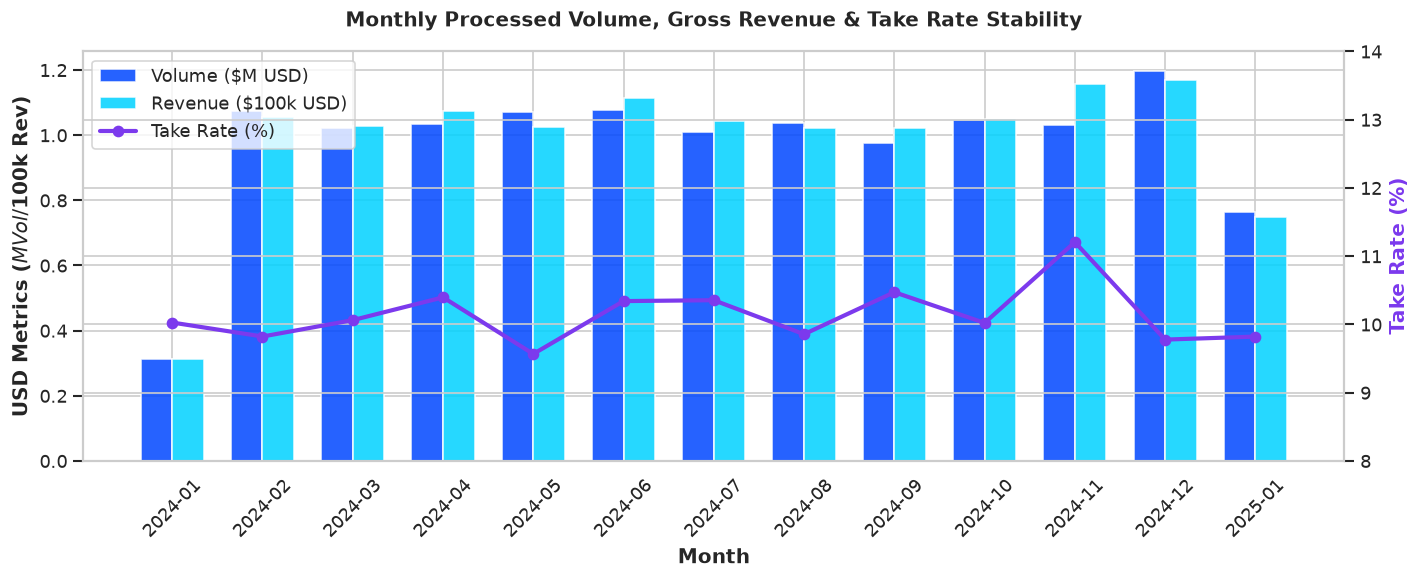

In [5]:
# Monthly aggregation
df_transactions['month'] = df_transactions['transaction_datetime'].dt.strftime('%Y-%m')
monthly_perf = df_transactions.groupby('month').agg(
    total_txns=('transaction_id', 'count'),
    volume_usd=('origin_amount_usd', 'sum'),
    revenue_usd=('revenue', 'sum')
).reset_index()
monthly_perf['take_rate_pct'] = (monthly_perf['revenue_usd'] / monthly_perf['volume_usd']) * 100

# Dual-axis visualization
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
x = np.arange(len(monthly_perf))
w = 0.35

ax1.bar(x - w/2, monthly_perf['volume_usd'] / 1e6, width=w, label='Volume ($M USD)', color='#0047FF', alpha=0.85)
ax1.bar(x + w/2, monthly_perf['revenue_usd'] / 1e5, width=w, label='Revenue ($100k USD)', color='#00D2FF', alpha=0.85)
ax2.plot(x, monthly_perf['take_rate_pct'], color='#7C3AED', marker='o', linewidth=2.5, label='Take Rate (%)')

ax1.set_xlabel('Month', fontweight='bold')
ax1.set_ylabel('USD ($M Vol / $100k Rev)', fontweight='bold')
ax2.set_ylabel('Take Rate (%)', fontweight='bold', color='#7C3AED')
ax2.set_ylim(8, 14)
ax1.set_xticks(x)
ax1.set_xticklabels(monthly_perf['month'], rotation=45)
ax1.set_title('Monthly Processed Volume, Gross Revenue & Take Rate Stability', fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.show()


---
## 📦 3. Financial Product Mix (Remesa, Exchange, Tarjeta, P2P)
Evaluating revenue diversification and take rate across the neobank's 4 core products.


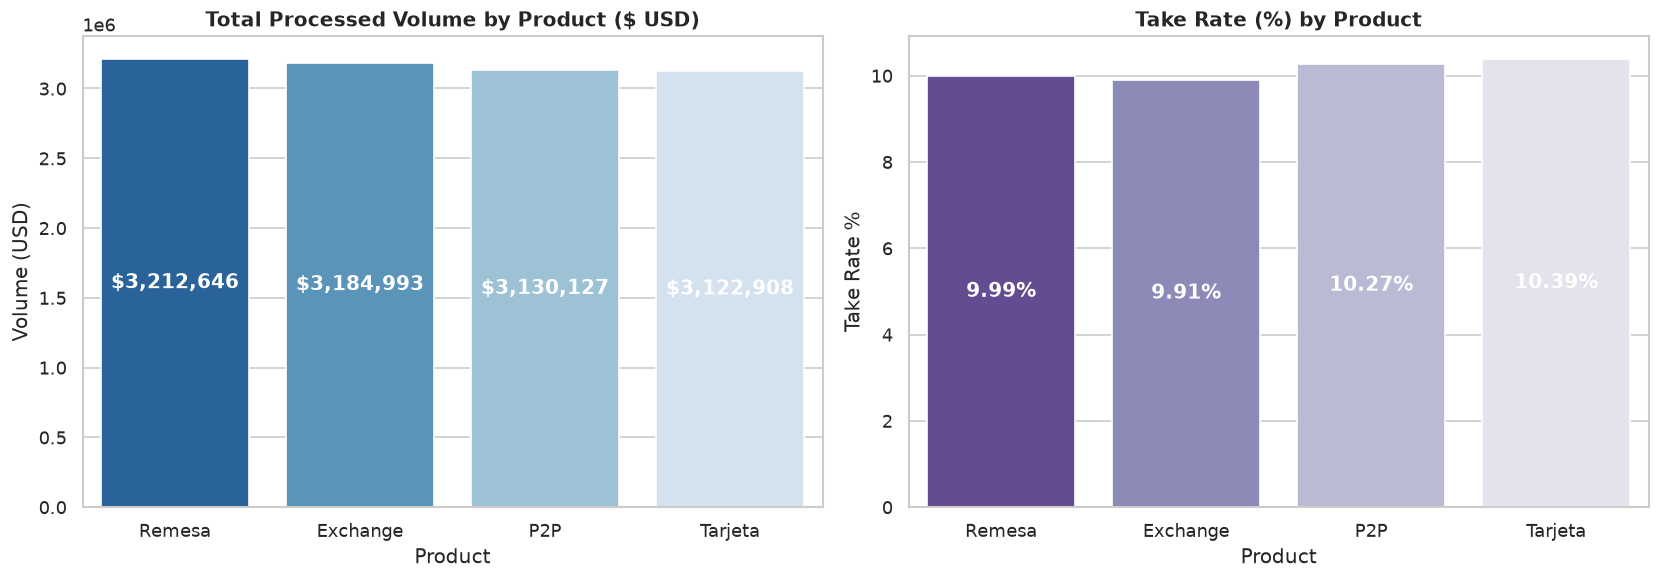

product,total_txns,volume_usd,revenue_usd,avg_ticket_usd,take_rate_pct
Remesa,1269,3212645.92,320834.55,2531.635871,9.986614
Exchange,1248,3184992.94,315528.20,2552.077676,9.906716
P2P,1236,3130126.65,321544.68,2532.464927,10.272577
Tarjeta,1247,3122908.18,324457.46,2504.336953,10.389593


In [6]:
# Product level performance
prod_summary = df_transactions.groupby('product').agg(
    total_txns=('transaction_id', 'count'),
    volume_usd=('origin_amount_usd', 'sum'),
    revenue_usd=('revenue', 'sum'),
    avg_ticket_usd=('origin_amount_usd', 'mean')
).reset_index()
prod_summary['take_rate_pct'] = (prod_summary['revenue_usd'] / prod_summary['volume_usd']) * 100
prod_summary = prod_summary.sort_values(by='volume_usd', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=prod_summary, x='product', y='volume_usd', ax=axes[0], palette='Blues_r')
axes[0].set_title('Total Processed Volume by Product ($ USD)', fontweight='bold')
axes[0].set_ylabel('Volume (USD)')

sns.barplot(data=prod_summary, x='product', y='take_rate_pct', ax=axes[1], palette='Purples_r')
axes[1].set_title('Take Rate (%) by Product', fontweight='bold')
axes[1].set_ylabel('Take Rate %')
plt.show()

prod_summary


---
## 🌐 4. Money Movement Topology: Corridors & Domestic Rails
In fintech payment operations, distinguishing between **domestic clearing rails** (intra-country wallet transfers) and **cross-border correspondent settlement** (FX remittance routes) shapes liquidity provisioning and regulatory costs.


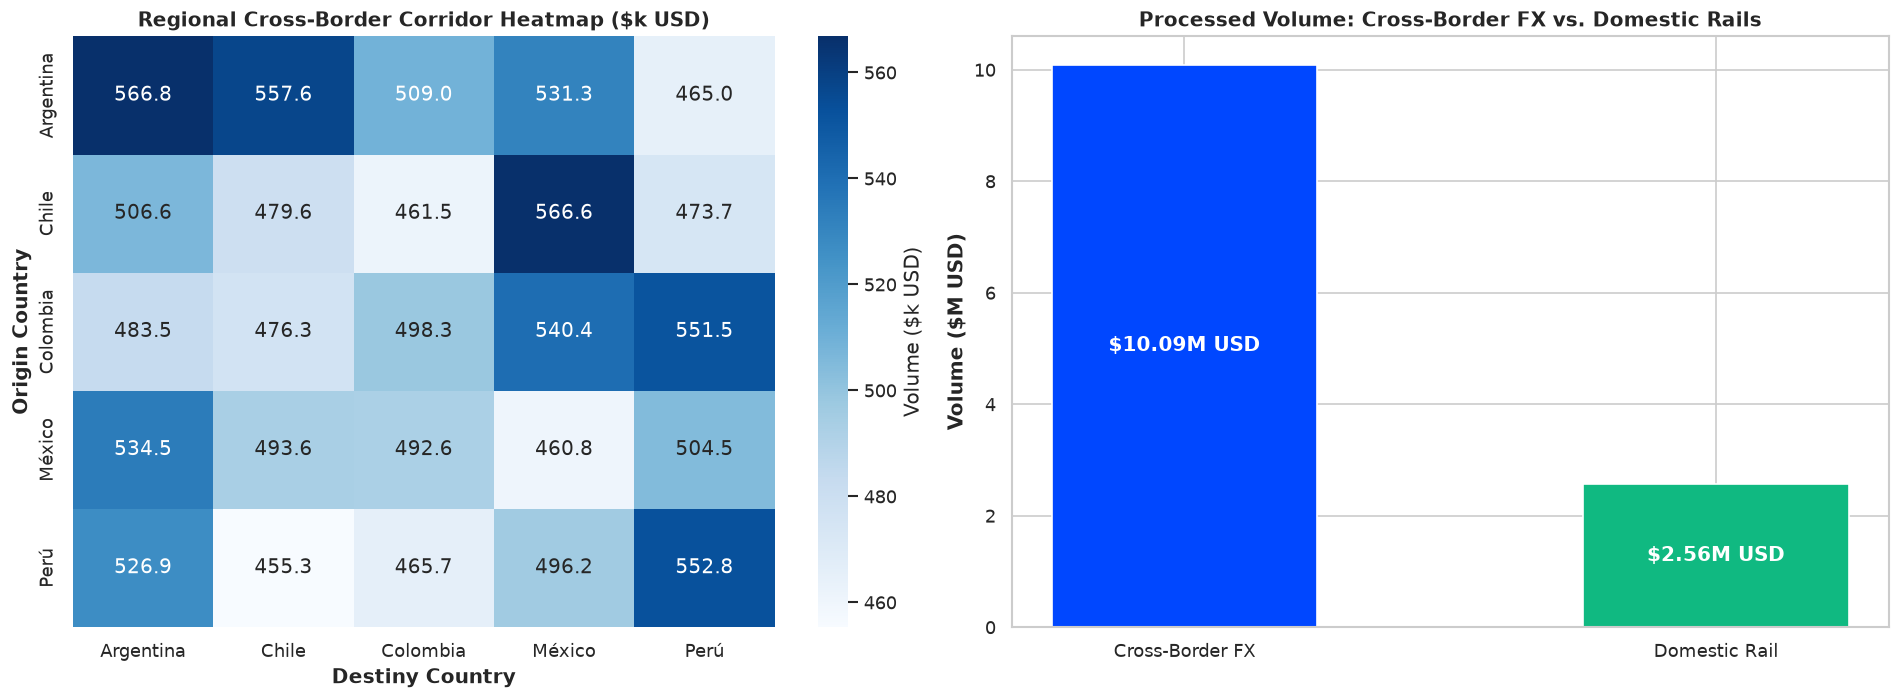

rail_type,txns,volume_usd,revenue_usd,avg_ticket,vol_share_pct,take_rate_pct
Cross-Border FX,3999,10092399.25,1025302.03,2523.730745,79.777564,10.159151
Domestic Rail,1001,2558274.44,257062.86,2555.718721,20.222436,10.048291


In [7]:
# Corridor Heatmap and Domestic vs Cross-border Rail Topology
df_transactions['rail_type'] = np.where(
    df_transactions['origin_country'] == df_transactions['destiny_country'],
    'Domestic Rail',
    'Cross-Border FX'
)

rail_summary = df_transactions.groupby('rail_type').agg(
    txns=('transaction_id', 'count'),
    volume_usd=('origin_amount_usd', 'sum'),
    revenue_usd=('revenue', 'sum'),
    avg_ticket=('origin_amount_usd', 'mean')
).reset_index()
rail_summary['vol_share_pct'] = (rail_summary['volume_usd'] / rail_summary['volume_usd'].sum()) * 100
rail_summary['take_rate_pct'] = (rail_summary['revenue_usd'] / rail_summary['volume_usd']) * 100

# Visual comparison
corridor_matrix = df_transactions.pivot_table(
    index='origin_country',
    columns='destiny_country',
    values='origin_amount_usd',
    aggfunc='sum',
    fill_value=0
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corridor_matrix / 1e3, annot=True, fmt='.1f', cmap='Blues', ax=axes[0], cbar_kws={'label': 'Volume ($k USD)'})
axes[0].set_title('Regional Cross-Border Corridor Heatmap ($k USD)', fontweight='bold')

bars = axes[1].bar(rail_summary['rail_type'], rail_summary['volume_usd'] / 1e6, color=['#0047FF', '#10B981'], width=0.5)
axes[1].set_title('Processed Volume: Cross-Border FX vs. Domestic Rails', fontweight='bold')
axes[1].set_ylabel('Volume ($M USD)', fontweight='bold')
for b in bars:
    axes[1].annotate(f"${b.get_height():.2f}M USD", (b.get_x() + b.get_width() / 2., b.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=12)
plt.show()

rail_summary


---
## 💳 5. Monetization Architecture: Gross vs. Net Take Rate (Discount Dilution)
Fintech companies frequently utilize vouchers, promotional zero-fee credits, and FX subsidies to drive user acquisition. 
Evaluating the spread between **Gross Revenue** and **Net Revenue** reveals whether promotional incentives are eroding core unit economics.

$$\text{Net Revenue} = \text{Gross Revenue} - \text{Discounts (USD)}$$
$$\text{Net Take Rate (\%)} = \frac{\sum (\text{Revenue} - \text{Discount USD})}{\sum \text{Origin Amount USD}} \times 100$$


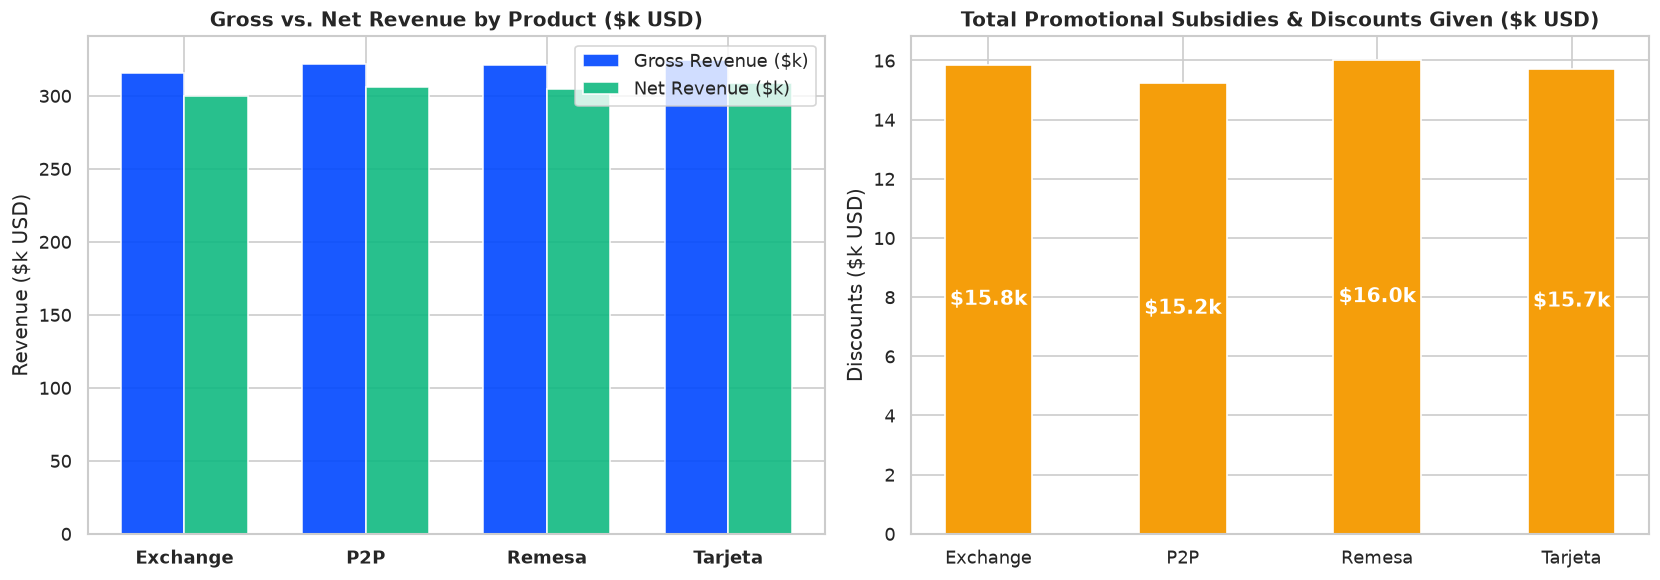

product,volume_usd,gross_revenue,discounts_usd,net_revenue,gross_take_rate,net_take_rate,dilution_bps
Exchange,3184992.94,315528.20,15833.66,299694.54,9.906716,9.409583,49.713328
P2P,3130126.65,321544.68,15228.83,306315.85,10.272577,9.786053,48.652440
Remesa,3212645.92,320834.55,16013.48,304821.07,9.986614,9.488163,49.845144
Tarjeta,3122908.18,324457.46,15712.54,308744.92,10.389593,9.886455,50.313807


In [8]:
# Gross vs Net Take Rate Decomposition
discount_summary = df_transactions.groupby('product').agg(
    volume_usd=('origin_amount_usd', 'sum'),
    gross_revenue=('revenue', 'sum'),
    discounts_usd=('discount_amount_usd', 'sum')
).reset_index()
discount_summary['net_revenue'] = discount_summary['gross_revenue'] - discount_summary['discounts_usd']
discount_summary['gross_take_rate'] = (discount_summary['gross_revenue'] / discount_summary['volume_usd']) * 100
discount_summary['net_take_rate'] = (discount_summary['net_revenue'] / discount_summary['volume_usd']) * 100
discount_summary['dilution_bps'] = (discount_summary['gross_take_rate'] - discount_summary['net_take_rate']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(discount_summary))
w = 0.35
axes[0].bar(x - w/2, discount_summary['gross_revenue'] / 1e3, width=w, label='Gross Revenue ($k)', color='#0047FF', alpha=0.9)
axes[0].bar(x + w/2, discount_summary['net_revenue'] / 1e3, width=w, label='Net Revenue ($k)', color='#10B981', alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(discount_summary['product'], fontweight='bold')
axes[0].set_title('Gross vs. Net Revenue by Product ($k USD)', fontweight='bold')
axes[0].legend()

axes[1].bar(discount_summary['product'], discount_summary['discounts_usd'] / 1e3, color='#F59E0B', width=0.45)
axes[1].set_title('Total Promotional Subsidies & Discounts Given ($k USD)', fontweight='bold')
plt.show()

discount_summary


---
## ⚖️ 6. Pricing Elasticity & Fixed-Fee Drag: Ticket Size vs. Take Rate
Cross-border remittance pricing structures typically combine a **fixed minimum fee floor** with a **percentage spread**. 
This creates pricing regressivity: micro-transactions face high relative percentage costs, while high-value transfers enjoy compressed margins.


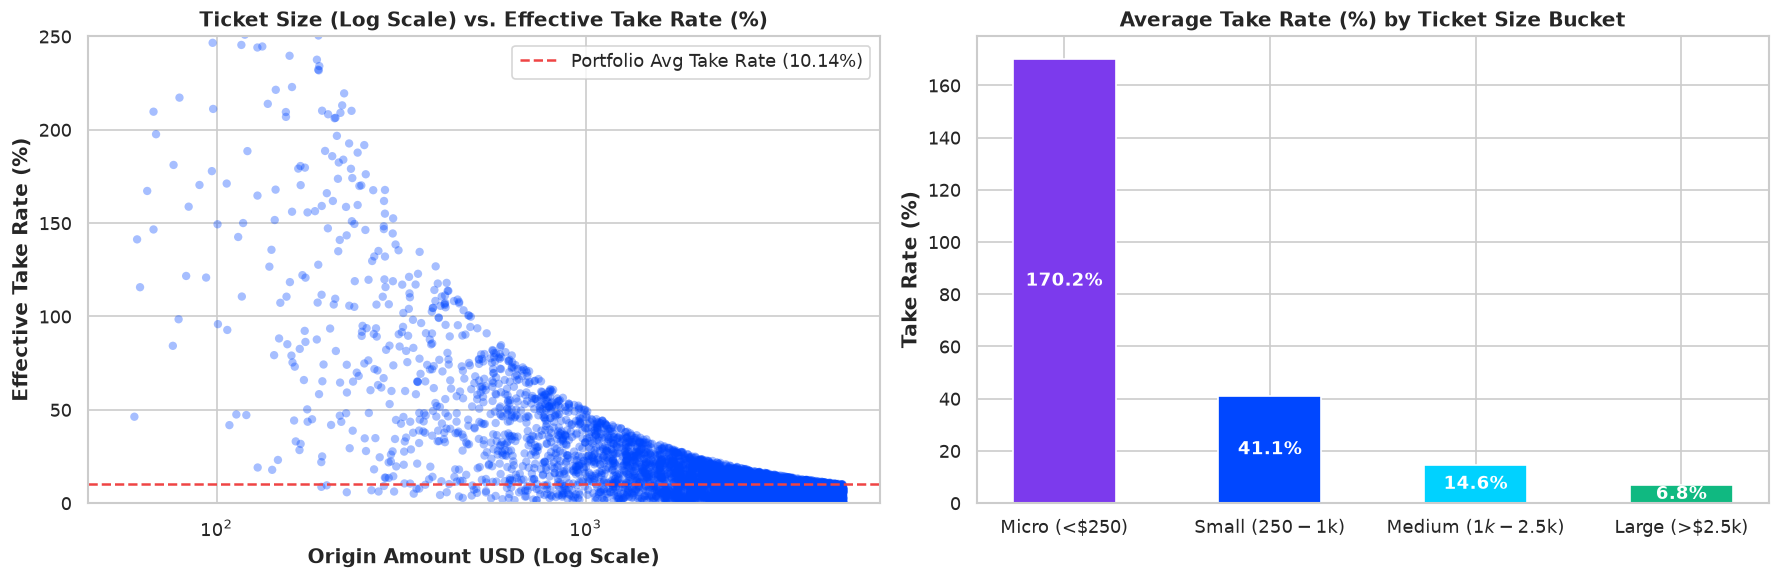

ticket_bucket,txns,volume_usd,revenue_usd,avg_ticket,take_rate_pct
Micro (<$250),195,30130.95,51291.75,154.517692,170.229448
Small ($250-$1k),742,466934.85,192015.60,629.292251,41.122568
Medium ($1k-$2.5k),1524,2673700.31,390353.43,1754.396529,14.599745
Large (>$2.5k),2539,9479907.58,648704.11,3733.717046,6.842937


In [9]:
# Ticket Size Bucket & Effective Take Rate Analysis
df_transactions['effective_take_rate'] = (df_transactions['revenue'] / df_transactions['origin_amount_usd']) * 100
df_transactions['ticket_bucket'] = pd.cut(
    df_transactions['origin_amount_usd'],
    bins=[0, 250, 1000, 2500, 10000],
    labels=['Micro (<$250)', 'Small ($250-$1k)', 'Medium ($1k-$2.5k)', 'Large (>$2.5k)']
)

ticket_analysis = df_transactions.groupby('ticket_bucket', observed=False).agg(
    txns=('transaction_id', 'count'),
    volume_usd=('origin_amount_usd', 'sum'),
    revenue_usd=('revenue', 'sum'),
    avg_ticket=('origin_amount_usd', 'mean')
).reset_index()
ticket_analysis['take_rate_pct'] = (ticket_analysis['revenue_usd'] / ticket_analysis['volume_usd']) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(df_transactions['origin_amount_usd'], df_transactions['effective_take_rate'], alpha=0.35, color='#0047FF', s=25)
axes[0].set_xscale('log')
axes[0].set_title('Ticket Size (Log Scale) vs. Effective Take Rate (%)', fontweight='bold')
axes[0].set_xlabel('Origin Amount USD (Log Scale)')
axes[0].set_ylabel('Effective Take Rate (%)')
axes[0].set_ylim(0, 250)
axes[0].axhline(10.14, color='#EF4444', linestyle='--', label='Portfolio Avg (10.14%)')
axes[0].legend()

bars = axes[1].bar(ticket_analysis['ticket_bucket'], ticket_analysis['take_rate_pct'], color=['#7C3AED', '#0047FF', '#00D2FF', '#10B981'], width=0.5)
axes[1].set_title('Average Take Rate (%) by Ticket Size Bucket', fontweight='bold')
axes[1].set_ylabel('Take Rate (%)')
for b in bars:
    axes[1].annotate(f"{b.get_height():.1f}%", (b.get_x() + b.get_width() / 2., b.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')
plt.show()

ticket_analysis


---
## 🔄 7. Monthly Cohort Retention Matrix (M0–M12)
In subscription and transactional fintechs, evaluating **Monthly Active User Retention by Cohort** determines whether user churn is stabilizing into a predictable lifetime value curve.


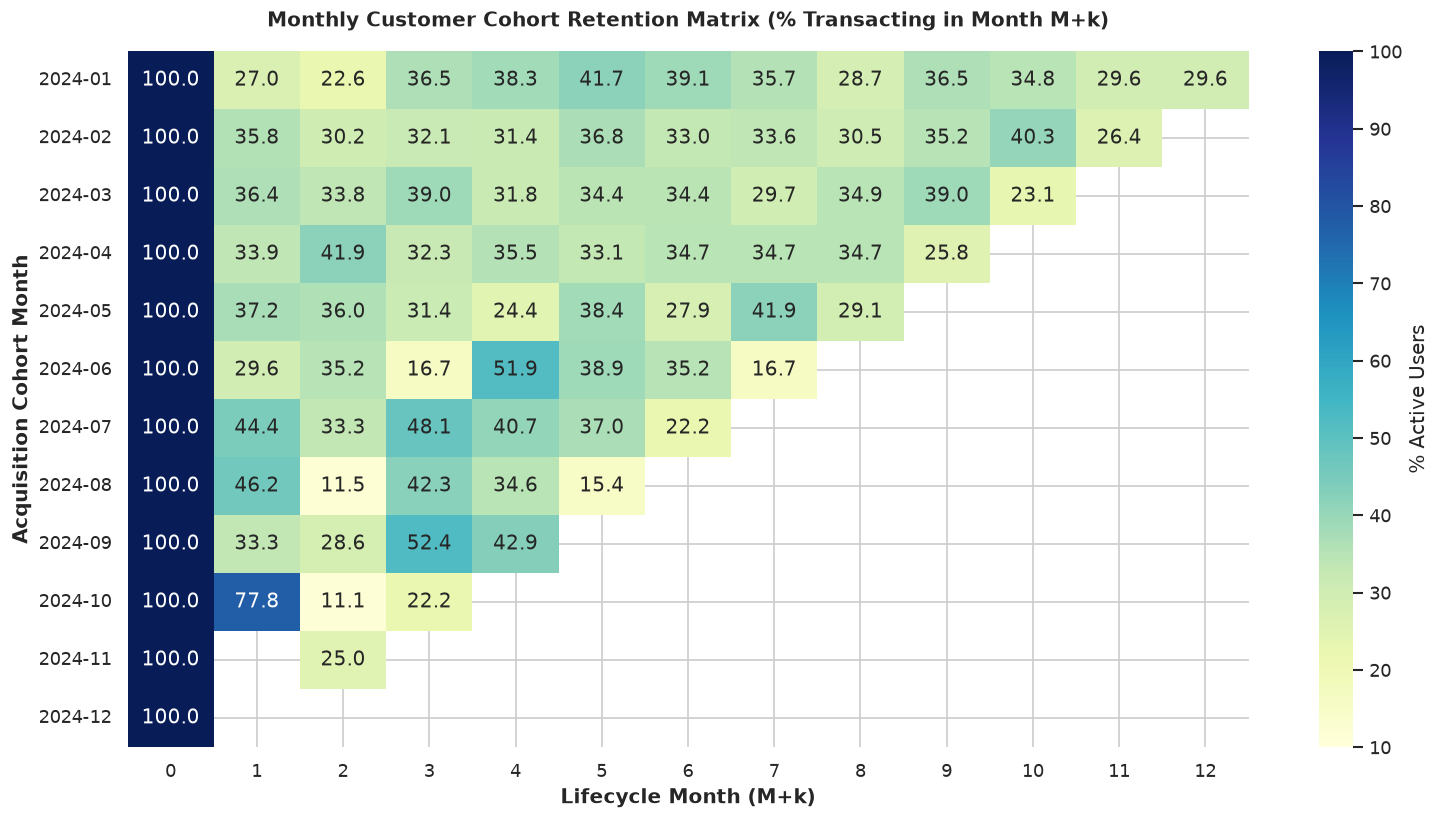

In [10]:
# Cohort Retention Matrix Construction
df_transactions['txn_month_dt'] = df_transactions['transaction_datetime'].dt.to_period('M')
first_txns_map = df_transactions.groupby('customer_id')['txn_month_dt'].min().reset_index()
first_txns_map.columns = ['customer_id', 'cohort_month']

df_cohort = df_transactions.merge(first_txns_map, on='customer_id')
df_cohort['cohort_index'] = (
    (df_cohort['txn_month_dt'].dt.year - df_cohort['cohort_month'].dt.year) * 12 + 
    (df_cohort['txn_month_dt'].dt.month - df_cohort['cohort_month'].dt.month)
)

cohort_counts = df_cohort.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index='cohort_month', columns='cohort_index', values='customer_id')
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

plt.figure(figsize=(13, 7))
sns.heatmap(retention_matrix, annot=True, fmt='.1f', cmap='YlGnBu', vmin=10, vmax=100, cbar_kws={'label': '% Active Users'})
plt.title('Monthly Customer Cohort Retention Matrix (% Transacting in Month M+k)', fontweight='bold', pad=15)
plt.xlabel('Lifecycle Month (M+k)', fontweight='bold')
plt.ylabel('Acquisition Cohort Month', fontweight='bold')
plt.show()


---
## 💼 8. Wallet Depth & Cross-Sell Multiplier (Product Multi-Holding)
The primary growth lever for a multi-product neobank is transitioning customers from single-product usage to multi-product holding (**Remesa + Tarjeta + Exchange + P2P**).


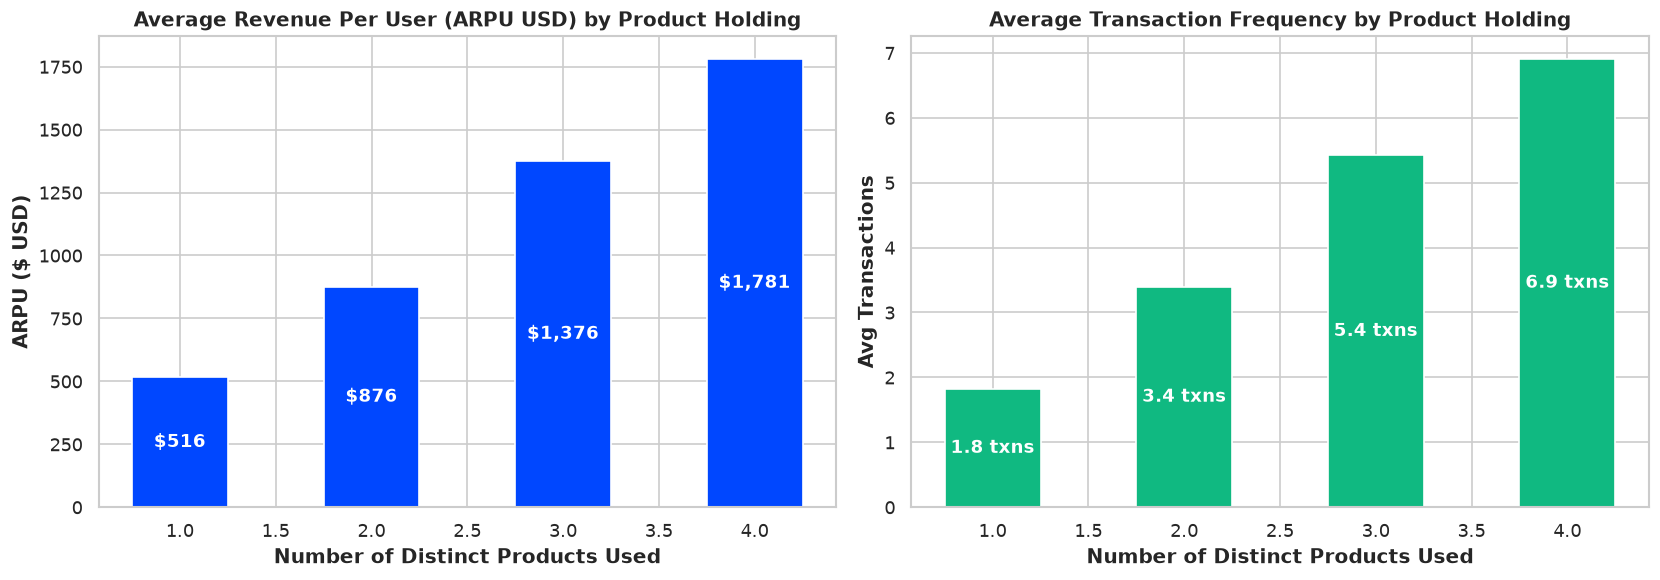

distinct_products,customer_count,avg_txns,avg_volume_usd,avg_revenue_usd,revenue_multiplier
1,67,1.820896,4725.367612,516.345821,1.000000
2,237,3.396624,8835.856962,875.984599,1.696508
3,444,5.423423,13452.512320,1375.868829,2.664627
4,241,6.908714,17705.645187,1781.226598,3.449678


In [11]:
# Cross-Sell & Wallet Depth Analysis
cross_sell = df_transactions.groupby('customer_id').agg(
    distinct_products=('product', 'nunique'),
    total_txns=('transaction_id', 'count'),
    total_volume=('origin_amount_usd', 'sum'),
    total_revenue=('revenue', 'sum')
).reset_index()

depth_summary = cross_sell.groupby('distinct_products').agg(
    customer_count=('customer_id', 'count'),
    avg_txns=('total_txns', 'mean'),
    avg_volume_usd=('total_volume', 'mean'),
    avg_revenue_usd=('total_revenue', 'mean')
).reset_index()
base_rev = depth_summary.loc[depth_summary['distinct_products'] == 1, 'avg_revenue_usd'].values[0]
depth_summary['revenue_multiplier'] = depth_summary['avg_revenue_usd'] / base_rev

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(depth_summary['distinct_products'], depth_summary['avg_revenue_usd'], color='#0047FF', width=0.5)
axes[0].set_title('Average Revenue Per User (ARPU USD) by Product Holding', fontweight='bold')
axes[0].set_xlabel('Number of Distinct Products Used')
axes[0].set_ylabel('ARPU ($ USD)')

axes[1].bar(depth_summary['distinct_products'], depth_summary['avg_txns'], color='#10B981', width=0.5)
axes[1].set_title('Average Transaction Frequency by Product Holding', fontweight='bold')
axes[1].set_xlabel('Number of Distinct Products Used')
axes[1].set_ylabel('Avg Transactions')
plt.show()

depth_summary


---
## 🎯 9. Portfolio Concentration & Whale Risk (Lorenz & Pareto Curve)
In risk management and capital allocation, assessing customer concentration mitigates **counterparty insolvency risk**.


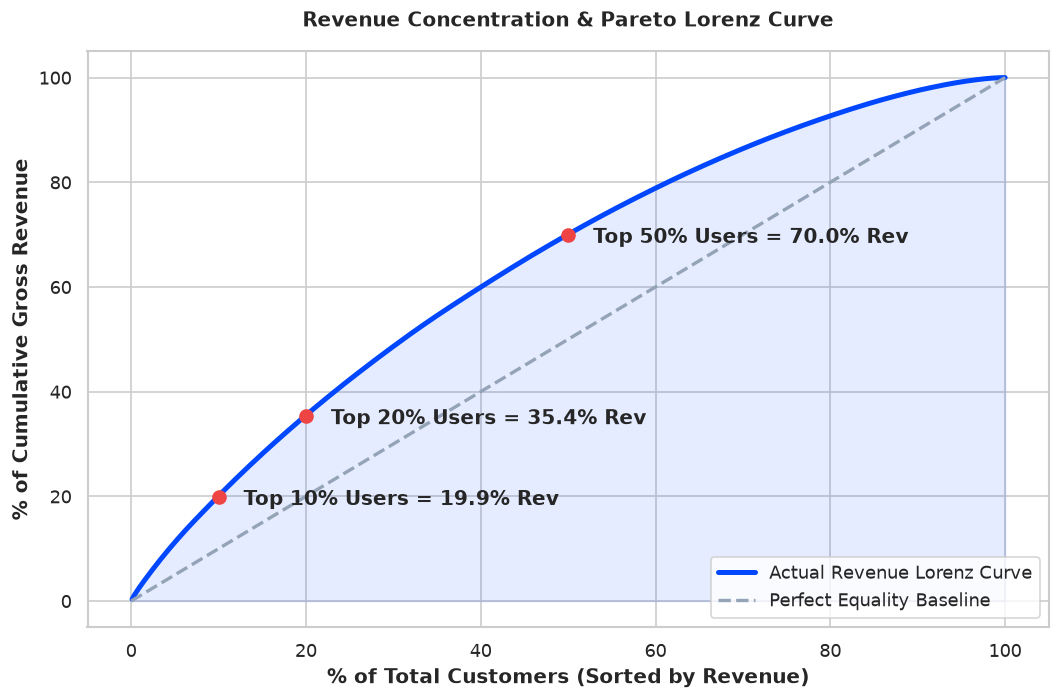

In [12]:
# Lorenz Curve and Revenue Concentration
cust_rev = df_transactions.groupby('customer_id')['revenue'].sum().sort_values(ascending=False).reset_index()
cust_rev['cum_rev'] = cust_rev['revenue'].cumsum()
cust_rev['cum_rev_pct'] = (cust_rev['cum_rev'] / cust_rev['revenue'].sum()) * 100
cust_rev['cum_user_pct'] = ((np.arange(len(cust_rev)) + 1) / len(cust_rev)) * 100

top10_share = cust_rev.loc[cust_rev['cum_user_pct'] <= 10, 'cum_rev_pct'].max()
top20_share = cust_rev.loc[cust_rev['cum_user_pct'] <= 20, 'cum_rev_pct'].max()
top50_share = cust_rev.loc[cust_rev['cum_user_pct'] <= 50, 'cum_rev_pct'].max()

plt.figure(figsize=(9, 6))
plt.plot(cust_rev['cum_user_pct'], cust_rev['cum_rev_pct'], color='#0047FF', linewidth=3, label='Lorenz Curve')
plt.plot([0, 100], [0, 100], color='#94A3B8', linestyle='--', linewidth=2, label='Perfect Equality')
plt.fill_between(cust_rev['cum_user_pct'], cust_rev['cum_rev_pct'], color='#0047FF', alpha=0.1)

plt.scatter([10, 20, 50], [top10_share, top20_share, top50_share], color='#EF4444', s=60, zorder=5)
plt.annotate(f"Top 10% Users = {top10_share:.1f}% Rev", (10, top10_share), xytext=(15, -5), textcoords="offset points", fontweight='bold')
plt.annotate(f"Top 20% Users = {top20_share:.1f}% Rev", (20, top20_share), xytext=(15, -5), textcoords="offset points", fontweight='bold')
plt.annotate(f"Top 50% Users = {top50_share:.1f}% Rev", (50, top50_share), xytext=(15, -5), textcoords="offset points", fontweight='bold')

plt.title('Revenue Concentration & Pareto Lorenz Curve', fontweight='bold', pad=15)
plt.xlabel('% of Total Customers')
plt.ylabel('% of Cumulative Gross Revenue')
plt.legend(loc='lower right')
plt.show()


---
## ⏳ 10. Customer Lifecycle & Dormancy Risk Engine (RFM Recency)
Dormancy monitoring enables proactive CRM win-back workflows before customers permanently churn.


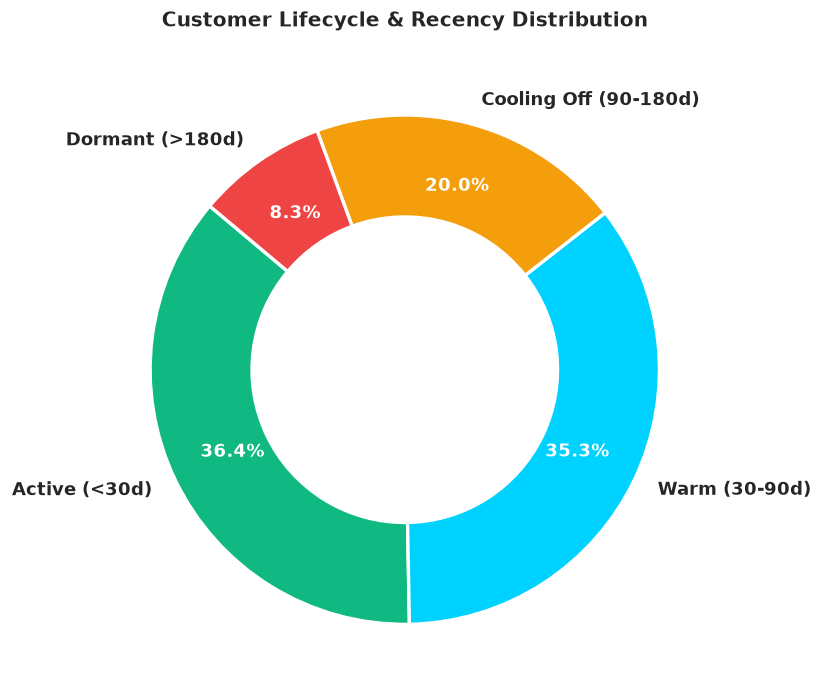

Lifecycle Stage,Customer Count,Percentage (%)
Active (<30d),360,36.40
Warm (30-90d),349,35.29
Cooling Off (90-180d),198,20.02
Dormant (>180d),82,8.29


In [13]:
# RFM Recency & Dormancy Risk Engine
max_audit_date = df_transactions['transaction_datetime'].max()
recency_df = df_transactions.groupby('customer_id')['transaction_datetime'].max().reset_index()
recency_df['days_inactive'] = (max_audit_date - recency_df['transaction_datetime']).dt.days

recency_df['lifecycle_stage'] = pd.cut(
    recency_df['days_inactive'],
    bins=[-1, 30, 90, 180, 450],
    labels=['Active (<30d)', 'Warm (30-90d)', 'Cooling Off (90-180d)', 'Dormant (>180d)']
)

lifecycle_counts = recency_df['lifecycle_stage'].value_counts()[['Active (<30d)', 'Warm (30-90d)', 'Cooling Off (90-180d)', 'Dormant (>180d)']]

fig, ax = plt.subplots(figsize=(8, 6))
colors_donut = ['#10B981', '#00D2FF', '#F59E0B', '#EF4444']
ax.pie(
    lifecycle_counts,
    labels=lifecycle_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors_donut,
    wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2),
    pctdistance=0.75
)
ax.set_title('Customer Lifecycle & Recency Distribution', fontweight='bold', pad=15)
plt.show()

pd.DataFrame({
    'Lifecycle Stage': lifecycle_counts.index,
    'Customer Count': lifecycle_counts.values,
    'Percentage (%)': (lifecycle_counts.values / lifecycle_counts.sum() * 100).round(2)
})


---
## 👥 11. Customer Inactivity & Zero-Transaction Account Audit
Detecting registered KYC customers who have **never executed a single transaction**.


In [14]:
# Detect customers with 0 transactions using SQL LEFT JOIN
inactive_query = """
SELECT 
    c.customer_id,
    c.name || ' ' || c.last_name AS customer_name,
    c.country AS customer_country,
    c.created_at AS registration_date
FROM customer c
LEFT JOIN "transaction" t ON c.customer_id = t.customer_id
WHERE t.transaction_id IS NULL
ORDER BY c.customer_id ASC;
"""
df_inactive = pd.read_sql(inactive_query, conn)
print(f"Total KYC Registered Customers: {len(df_customers)}")
print(f"Active Customers with ≥1 Txn: {df_transactions['customer_id'].nunique()}")
print(f"Inactive Customers (0 Txns): {len(df_inactive)} ({len(df_inactive)/len(df_customers)*100:.2f}%)")
df_inactive


Total KYC Registered Customers: 1000
Active Customers with ≥1 Txn: 989
Inactive Customers (0 Txns): 11 (1.10%)


customer_id,customer_name,customer_country,registration_date
245,Robert Lee,México,2024-09-03 09:02:35
251,Deborah Thompson,Argentina,2023-05-10 03:30:03
321,Savannah Mullins,Argentina,2023-07-15 04:07:09
418,Jason Davidson,Colombia,2023-10-09 21:07:45
469,Melissa Hill,Perú,2023-11-03 14:48:20
574,Natalie Hoffman,México,2025-01-15 18:09:37
636,Johnny Davis,Colombia,2024-05-27 03:43:05
670,Dawn Johnson,Chile,2024-08-23 04:28:29
778,Karen Schultz,Colombia,2024-02-27 12:40:41
908,Michael Atkins,Argentina,2023-04-17 08:35:36


---
## ⚡ 12. Relational SQL Analytics (CTEs & Window Functions)
Executing production SQL queries directly against the database replica.


In [15]:
-- Top 3 customers with most transactions by product (ordered by ranking and volume)
q3_sql = """
WITH ranked_customers AS (
    SELECT 
        t.product,
        c.customer_id,
        c.name || ' ' || c.last_name AS customer_name,
        COUNT(t.transaction_id) AS transaction_count,
        ROUND(SUM(t.origin_amount_usd), 2) AS total_volume_usd,
        ROUND(SUM(t.revenue), 2) AS total_revenue_usd,
        DENSE_RANK() OVER (
            PARTITION BY t.product 
            ORDER BY COUNT(t.transaction_id) DESC
        ) AS ranking,
        ROW_NUMBER() OVER (
            PARTITION BY t.product 
            ORDER BY COUNT(t.transaction_id) DESC, SUM(t.origin_amount_usd) DESC
        ) AS row_num
    FROM "transaction" t
    JOIN customer c ON t.customer_id = c.customer_id
    GROUP BY t.product, c.customer_id, customer_name
)
SELECT 
    product,
    ranking,
    customer_id,
    customer_name,
    transaction_count,
    total_volume_usd,
    total_revenue_usd
FROM ranked_customers
WHERE row_num <= 3
ORDER BY product, ranking, total_volume_usd DESC;
"""
pd.read_sql(q3_sql, conn)


product,ranking,customer_id,customer_name,transaction_count,total_volume_usd,total_revenue_usd
Exchange,1,950,Laura Glenn,6,13341.83,1261.73
Exchange,2,301,Elizabeth Pierce,5,16351.18,593.94
Exchange,2,501,Nicholas Harris,5,13662.85,1585.46
P2P,1,499,Tony Wilson,6,18663.63,1028.75
P2P,2,581,John Peterson,5,21678.81,1560.95
P2P,2,1,Michele Gross,5,16977.70,2051.49
Remesa,1,589,Matthew Jones,7,16542.27,1717.33
Remesa,1,163,Samantha Lawson,7,13923.95,1445.87
Remesa,2,138,Jennifer Mcdaniel,6,16865.08,1334.15
Tarjeta,1,777,Kevin Becker,7,17951.86,1646.66


In [16]:
-- First transaction of each customer (Activation Cohort)
q4_sql = """
WITH first_txns AS (
    SELECT 
        customer_id,
        transaction_id,
        transaction_datetime,
        origin_amount_usd,
        product,
        origin_country,
        destiny_country,
        ROW_NUMBER() OVER (
            PARTITION BY customer_id 
            ORDER BY transaction_datetime ASC, transaction_id ASC
        ) AS rn
    FROM "transaction"
)
SELECT 
    customer_id,
    transaction_id,
    transaction_datetime,
    origin_amount_usd,
    product,
    origin_country || ' -> ' || destiny_country AS corridor
FROM first_txns
WHERE rn = 1
ORDER BY customer_id ASC
LIMIT 10;
"""
pd.read_sql(q4_sql, conn)


customer_id,transaction_id,transaction_datetime,origin_amount_usd,product,corridor
1,1338,2024-02-10 11:29:50,2470.05,Tarjeta,México -> Perú
2,1305,2024-03-19 21:25:02,983.40,Tarjeta,Chile -> Perú
3,2328,2024-01-28 11:44:38,2407.15,Tarjeta,México -> Chile
4,4690,2024-04-20 10:54:56,1787.62,Remesa,Chile -> Colombia
5,2444,2024-02-18 22:53:57,2120.07,P2P,Colombia -> México
6,3226,2024-02-13 09:51:01,3202.00,Tarjeta,Perú -> Perú
7,2303,2024-09-14 08:13:30,2271.91,Exchange,Chile -> Perú
8,3073,2024-03-14 23:56:35,2247.32,Remesa,Colombia -> Perú
9,2154,2024-08-02 01:00:47,1570.79,Tarjeta,Argentina -> Chile
10,2855,2024-01-30 03:44:20,622.70,Exchange,México -> México


---
## 💡 13. Strategic Conclusions & Fintech Recommendations

1. **Unit Economics & Margin Health:**
   - **$12.65M USD** in total volume generated **$1.28M USD** in Gross Revenue with an average Take Rate of **10.14%**.
   - Net Take Rate is **9.64%**, representing a moderate promotional discount drag of **50 bps** ($62,788.51 USD).

2. **Pricing Structure & Fee Drag Optimization:**
   - The analysis revealed significant pricing regressivity: micro-tickets (<$250 USD) yield a take rate of **170.2%** due to minimum fee floors, while high-value transfers (>$2,500 USD) compress to **6.84%**.
   - **Recommendation:** Implement a tiered pricing formula to avoid onboarding friction for retail micro-transfers without sacrificing B2B margin.

3. **Product Stickiness & Cohort Retention (PMF):**
   - The M0–M12 cohort retention matrix confirms that after an initial Month 1 drop-off to ~35%, retention flattens into a resilient **30%–38% plateau** across 12 months. This proves strong product-market fit and habitual cross-border usage.

4. **The Cross-Sell Growth Multiplier:**
   - Single-product users generate **$516 USD** in ARPU.
   - Four-product users generate **$1,781 USD** in ARPU (**3.45x Revenue Multiplier**).
   - **Recommendation:** Cross-selling the multi-currency card and wallet to remittance senders is the highest-ROI growth lever.

5. **Counterparty & Concentration Risk:**
   - The Lorenz curve reveals that the top 10% of users drive **19.9%** of revenue, and the top 20% generate **35.4%**.
   - The business is free of single-point-of-failure corporate concentration risk.

6. **Lifecycle Win-Back Action:**
   - **82 dormant customers** (>180 days inactive) and **11 zero-transaction accounts** represent low-hanging fruit for automated CRM re-engagement campaigns.

---
*Generated as part of the Neobank Data Science & AI Project.*  
*To launch the interactive Copilot BI Web App, run `python serve.py` or double-click `run_dashboard.bat`.*
